In [1]:
import os
import requests
from numpy import dtype

# fix
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
# os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ['CUDA_VISIBLE_DEVICES'] = "0"
import torch
from pystac_client import Client
from torch.utils.data import Dataset
import rasterio
from rasterio.windows import Window
import re
import pickle
import tqdm
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
from sklearn.metrics import f1_score
import torch.nn as nn
from skimage.transform import resize


#Check if CUDA is available
try:
    if torch.cuda.is_available():
        print('CUDA is available. Using GPU...')
        device = torch.device('cuda')
        device_str = 'cuda'
    elif torch.backends.mps.is_available():
        print('MPS is available. Using MPS...')
        device = torch.device('mps')
        device_str = 'mps'
    else:
        print('CUDA/MPS is not available. Using CPU...')
        device = torch.device('cpu')
        device_str = 'cpu'
except Exception as e:
    device = torch.device('cpu')
    device_str = 'cpu'
    print(f'Error during device detection using CPU... {e}')

print(f'Using device: {device}')

MPS is available. Using MPS...
Using device: mps


In [2]:
#query and download data from STAC for inference
stac_endpoint = 'stac.sage.uvt.ro'
catalog = Client.open(f"https://{stac_endpoint}/")
query = catalog.search(
    collections=["sentinel-2-l1c"],
    datetime="2024-09-01/2024-09-30",
    bbox=[20.2201924985, 43.6884447292, 29.62654341, 48.2208812526],
    query={"eo:cloud_cover": {"lt": 5},
           "s2:mgrs_tile": dict(eq="T35TMN")
           },
)
items = list(query.items())
print(f"Found {len(items)} items")
print(items)

Found 3 items
[<Item id=S2B_MSIL1C_20240924T092029_N0511_R093_T35TMN_20240924T112403>, <Item id=S2B_MSIL1C_20240921T090559_N0511_R050_T35TMN_20240921T110827>, <Item id=S2A_MSIL1C_20240909T092031_N0511_R093_T35TMN_20240909T112152>]


In [3]:
#download the item

inference_dir = "inference_data"
inference_data_dir = f"{inference_dir}/raw"
os.makedirs(inference_data_dir, exist_ok=True)

stac_catalog = 'sentinel-2-l1c'
bands_of_interest = ["B02", "B03", "B04", "B08", "B05", "B06", "B07", "B8A", "fmask"] # what to download

s2_ids = [item.id for item in items]

def download_items(s2_ids,
                   raw_data_dir,
                   stac_endpoint,
                   stac_catalog,
                   bands_of_interest):
    print(f"Downloading {len(s2_ids)} Sentinel 2 items...")
    for s2_id in tqdm.tqdm(s2_ids):
        try:
            resp_id = requests.get(f"https://{stac_endpoint}/collections/{stac_catalog}/items/{s2_id}")
        except Exception as e:
            print(f"Error fetching item {s2_id}: {e}")
            continue
        if resp_id.status_code != 200:
            print(f"Failed to retrieve item {s2_id}: Status code {resp_id.status_code}")
            continue
        for asset_key, assets in resp_id.json()['assets'].items():
            if os.path.exists(f"{raw_data_dir}/{s2_id}/{s2_id}_{asset_key}.tif"):
                # print(f"File {raw_data_dir}/{s2_id}/{s2_id}_{asset_key}.tif already exists. Skipping download.")
                continue
            if asset_key in bands_of_interest:
                try:
                    resp = requests.get(assets['href'])
                except Exception as e:
                    print(f"Error fetching {assets['href']}: {e}")

                #save cog
                if not os.path.exists(f"{raw_data_dir}/{s2_id}"):
                    os.makedirs(f"{raw_data_dir}/{s2_id}")
                with open(f"{raw_data_dir}/{s2_id}/{s2_id}_{asset_key}.tif", "wb") as file:
                    file.write(resp.content)


download_items([s2_ids[0]], inference_data_dir, stac_endpoint, stac_catalog, bands_of_interest)

100%|██████████| 1/1 [00:00<00:00, 11.48it/s]


In [4]:
from typing import List, Dict, Optional, Callable, Tuple, Set
from contextlib import nullcontext
from rasterio.warp import reproject, Resampling
class Sentinel2MultiGranuleDataset(Dataset):
    """
    Iterate over multiple Sentinel-2 granule directories.
    Each __getitem__(idx) returns all 256x256 tiles (and GTI tiles) for one base scene
    found in one of the provided directories, walking dirs in sequence.

    Notes:
      - Keeps your on-disk 20m->10m ".rescaled" caching for B05/B06/B07/B8A.
      - If you used a single GTI file before, you can keep doing so (applied to every sample),
        or pass a per-directory mapping/callable that resolves the GTI file per granule.
    """
    def __init__(self,
                 directories: List[str],
                 gti_file: Optional[str] = None,
                 gti_by_dir: Optional[Dict[str, str]] = None,
                 gti_resolver: Optional[Callable[[str, str], str]] = None,
                 label: int = 10,           # tree class id
                 cloud_labels: List[int] = [0, 1, 1, 1, 1], # fmask normal/cloud/shadow/snow/water
                 stride: int = 256,
                 tile_size: int = 256,
                 img_size = (10980, 10980),
                 scalers: Optional[Dict[str, object]] = None,
                 transform: Optional[Callable] = None,
                 inference_mode: bool = False):
        """
        Args:
            directories: list of directories, each containing TIFs for one S2 granule.
            gti_file: single GTI file used for all samples (legacy behavior).
            gti_by_dir: optional mapping {directory: gti_path}.
            gti_resolver: optional callable (directory, base_file) -> gti_path.
            label: positive class id in GTI to map to 1.
            stride: sliding window step (px).
            scalers: optional dict of StandardScaler-like objects keyed by 'B02','B03',...
            inference_mode: optional bool, ignores GTI requirements for inference only
        """
        self.directories = [os.path.abspath(d) for d in directories]
        self.gti_file = gti_file
        self.gti_by_dir = gti_by_dir or {}
        self.gti_resolver = gti_resolver
        self.label = label
        self.stride = stride
        self.tile_size = tile_size
        self.img_size = img_size
        self.cloud_labels = cloud_labels  # fmask cloud/shadow/snow/water
        self.transform = transform
        self.scalers = scalers

        #build (directory, base_file) index across all provided directories
        #accept B02,B03,B04,B05,B06,B07,B08,B8A patterns
        band_pat = re.compile(r'^(?P<base>.+?)_(?:B02|B03|B04|B05|B06|B07|B08|B8A|fmask)\.tif$')
        self.samples: List[Tuple[str, str]] = []

        for d in self.directories:
            if not os.path.isdir(d):
                continue
            bases = set()
            for fname in os.listdir(d):
                if not fname.endswith('.tif'):
                    continue
                m = band_pat.match(fname)
                if m:
                    bases.add(m.group('base'))
            #keep deterministic order
            for base in sorted(bases):
                #ensure mandatory 10m bands exist (B02,B03,B04,B08)
                needed = [f"{base}_B02.tif", f"{base}_B03.tif", f"{base}_B04.tif", f"{base}_B08.tif"]
                if all(os.path.isfile(os.path.join(d, n)) for n in needed):
                    self.samples.append((d, base))

        if len(self.samples) == 0:
            raise RuntimeError("No valid Sentinel-2 base scenes found in the provided directories.")

        self.tile_index = []
        self.scenes = self.samples
        # You can open one 10m band just to get height/width
        # with rasterio.open(os.path.join(d, f"{base}_B02.tif")) as src:
        #         H, W = src.height, src.width
        H, W = self.img_size

        #todo check for fila name in scenes
        s_idx = 0
        # Precompute tile origins (row, col) so the last tile touches right/bottom edges
        rows = self._inclusive_starts(H, self.tile_size, self.stride)
        cols = self._inclusive_starts(W,  self.tile_size, self.stride)
        # self.tile_index: List[Tuple[int, int, int]] = [(s_idx, r, c) for r in rows for c in cols]
        self.tile_index: List[Tuple[str, int, int, int]] = []

        for s_idx, (d, base) in enumerate(self.scenes):
            for row in rows:
                for col in cols:
                    self.tile_index.append((base, s_idx, row, col))

        self.inference_mode = inference_mode

    def __len__(self):
        return len(self.tile_index)

    def _inclusive_starts(self, total: int, tile: int, stride: int) -> List[int]:
        """Generate start indices so that the *last* tile always touches the border."""
        if stride <= 0:
            raise ValueError("stride must be > 0")
        starts = list(range(0, max(total - tile, 0) + 1, stride))
        last = total - tile
        if last >= 0 and (not starts or starts[-1] != last):
            starts.append(last)
        return starts


    def __scale(self, data, band):
        if self.scalers is None:
            return data
        mean = self.scalers[band].mean_
        std = self.scalers[band].scale_
        return (data - mean) / std


    def _resolve_gti(self, directory: str, base_file: str, inference=False):
        # Priority: per-callable > per-dir map > single gti
        if inference:
            return None
        if self.gti_resolver is not None:
            return self.gti_resolver(directory, base_file)
        if directory in self.gti_by_dir:
            return self.gti_by_dir[directory]
        if self.gti_file is not None:
            return self.gti_file
        raise RuntimeError(
            f"GTI file not provided. Supply gti_file, gti_by_dir['{directory}'], or gti_resolver."
        )

    def _resolve_cloud_mask(self, directory: str, base_file: str) -> Optional[str]:
        #cloud mask lives next to bands and ends with "_fmask.tif"
        cand = os.path.join(directory, f"{base_file}_fmask.tif")
        return cand if os.path.isfile(cand) else None

    def __getitem__(self, idx):
        base_name, s_idx, i, j = self.tile_index[idx]
        directory, base_file = self.scenes[s_idx]

        file_b2 = os.path.join(directory, f"{base_file}_B02.tif")
        file_b3 = os.path.join(directory, f"{base_file}_B03.tif")
        file_b4 = os.path.join(directory, f"{base_file}_B04.tif")
        file_b8 = os.path.join(directory, f"{base_file}_B08.tif")
        file_5  = os.path.join(directory, f"{base_file}_B05.tif")
        file_6  = os.path.join(directory, f"{base_file}_B06.tif")
        file_7  = os.path.join(directory, f"{base_file}_B07.tif")
        file_8a = os.path.join(directory, f"{base_file}_B8A.tif")

        # Prepare rescaled (20m -> 10m) cache files beside the originals
        rs_5  = f"{file_5}.rescaled"
        rs_6  = f"{file_6}.rescaled"
        rs_7  = f"{file_7}.rescaled"
        rs_8a = f"{file_8a}.rescaled"

        # Create cache if missing (keeps your original approach)
        need_rescale = not (os.path.isfile(rs_5) and os.path.isfile(rs_6)
                            and os.path.isfile(rs_7) and os.path.isfile(rs_8a))
        if need_rescale:
            print(f"Rescaling 20m bands to 10m and caching for {base_file} in {directory}")
            with rasterio.open(file_5) as src_5, \
                 rasterio.open(file_6) as src_6, \
                 rasterio.open(file_7) as src_7, \
                 rasterio.open(file_8a) as src_8a, \
                 rasterio.open(file_b2) as src_b2:
                #target size (10m grid is 10980x10980 for S2 full granule at 10m)

                ref_profile = src_b2.profile.copy()
                ref_profile.update(
                    count=1,
                    dtype="uint16",                 # or "float32" if you really want floats
                    compress="DEFLATE",
                    tiled=True, blockxsize=256, blockysize=256,
                    BIGTIFF="IF_NEEDED",
                    predictor=1,                    # use 2 if dtype is float32
                    nodata=0                        # typical for S2 uint16 reflectance
                )
                H, W = src_b2.height, src_b2.width
                ref_tr  = src_b2.transform
                ref_crs = src_b2.crs

                def _resample_write(src_ds, out_path):
                    # resample in float32 then cast
                    work = np.empty((H, W), dtype=np.float32)
                    reproject(
                        source=rasterio.band(src_ds, 1),
                        destination=work,
                        src_transform=src_ds.transform, src_crs=src_ds.crs,
                        dst_transform=ref_tr,          dst_crs=ref_crs,
                        dst_width=W, dst_height=H,
                        resampling=Resampling.bilinear,
                    )
                    out = np.clip(work, 0, 10000).astype(np.uint16)  # keep S2 reflectance scale on disk
                    with rasterio.open(out_path, "w", **ref_profile) as dst:
                        dst.write(out, 1)

                # Build the four aligned caches
                _resample_write(src_5,  rs_5)
                _resample_write(src_6,  rs_6)
                _resample_write(src_7,  rs_7)
                _resample_write(src_8a, rs_8a)




        gti_path = self._resolve_gti(directory, base_file, self.inference_mode)
        cm_path  = self._resolve_cloud_mask(directory, base_file)

        window = Window(j, i, self.tile_size, self.tile_size)
        with rasterio.open(file_b2) as src_b2, \
             rasterio.open(file_b3) as src_b3, \
             rasterio.open(file_b4) as src_b4, \
             rasterio.open(file_b8) as src_b8, \
             rasterio.open(rs_5) as src_5, \
             rasterio.open(rs_6) as src_6, \
             rasterio.open(rs_7) as src_7, \
             rasterio.open(rs_8a) as src_8a, \
             rasterio.open(gti_path) if gti_path else nullcontext(None) as gti, \
             rasterio.open(cm_path) if cm_path else nullcontext(None) as cm:


            tile_b2  = src_b2.read(1, window=window)
            tile_b3  = src_b3.read(1, window=window)
            tile_b4  = src_b4.read(1, window=window)
            tile_b8  = src_b8.read(1, window=window)
            tile_b5  = src_5.read(1, window=window)
            tile_b6  = src_6.read(1, window=window)
            tile_b7  = src_7.read(1, window=window)
            tile_b8a = src_8a.read(1, window=window)
            if gti_path:
                tile_gti = gti.read(1, window=window)
            # if cm_path:
            #     tile_cm = cm.read(1, window=window)
            #     # process mask
            #     # Cloud/shadow/snow/water labels in fmask: 3,8,9,10,11
            #     print(self.cloud_labels)
            #     print(np.unique(tile_cm, return_counts=True))
            #     tile_cm[tile_cm == 1]  = self.cloud_labels[0]
            #     tile_cm[tile_cm == 2]  = self.cloud_labels[1]
            #     tile_cm[tile_cm == 3]  = self.cloud_labels[2]
            #     tile_cm[tile_cm == 4]  = self.cloud_labels[3]
            #     tile_cm[tile_cm == 5]  = self.cloud_labels[4]
            #
            #     # print(tile_cm.shape, tile_gti.shape)
            #     #fmask elements set to 1 for conveniance
            #     try:
            #         tile_gti = np.where(tile_cm == 1, tile_gti, 0.0)
            #     except Exception as e:
            #         # print(f"Error applying cloud mask: {e}")
            #         pass

            if self.scalers is not None:
                tile_b2  = self.__scale(tile_b2, 'B02')
                tile_b3  = self.__scale(tile_b3, 'B03')
                tile_b4  = self.__scale(tile_b4, 'B04')
                tile_b8  = self.__scale(tile_b8, 'B08')
                tile_b5  = self.__scale(tile_b5, 'B05')
                tile_b6  = self.__scale(tile_b6, 'B06')
                tile_b7  = self.__scale(tile_b7, 'B07')
                tile_b8a = self.__scale(tile_b8a, 'B8A')

            stack_list = [
                tile_b4,
                tile_b3,
                tile_b2,
                tile_b8,
                tile_b5,
                tile_b6,
                tile_b7,
                tile_b8a
            ]

            tile = np.dstack(stack_list).astype(np.float32)

            if gti_path:
                # GTI -> binary CLC 2018
                tile_gti[tile_gti == 244] = self.label
                tile_gti[tile_gti == 311] = self.label
                tile_gti[tile_gti == 312] = self.label
                tile_gti[tile_gti == 313] = self.label
                #transitional
                # img_clc[img_clc == 324] = 0
                #filter anything which is not forest
                tile_gti[tile_gti != self.label] = 0

                tile_gti = np.where(tile_gti == self.label, 1, 0).astype(np.float32)
                # tile_gti = (tile_gti == self.label).astype(np.float32)
            else:
                tile_gti = []

            # If no scalers, normalize reflectances to [0,1]
            if self.scalers is None:
                tile = tile / 10000.0

            if self.transform:
                tile = self.transform(tile)
                if gti_path:
                    tile_gti = self.transform(tile_gti)
                else:
                    tile_gti = torch.tensor([i,j], dtype=torch.int64)
                    # tile_gti = torch.tensor(idx, dtype=torch.int64)


        return tile, tile_gti

In [5]:
dataset_inference = Sentinel2MultiGranuleDataset(
    directories=[os.path.join(inference_data_dir, d) for d in os.listdir(inference_data_dir) if os.path.isdir(os.path.join(inference_data_dir, d))],
    gti_file=None,
    label=10,
    stride=320,
    tile_size=512,
    scalers=None,  # or provide pre-fitted scalers
    transform=transforms.ToTensor(),
    inference_mode=True)
dataloader_inference = DataLoader(dataset_inference,
                                  batch_size=1,
                                  shuffle=False)

In [6]:
dataloader_iter = iter(dataloader_inference)
images_out, pos = dataloader_iter.__next__()

In [7]:
images_out.shape

torch.Size([1, 8, 512, 512])

In [8]:
len(pos)

1

In [12]:
#load model
#Define model AttentionUNet



#####
class DoubleConv(nn.Module):
    """
    Deeper architecture
    """
    def __init__(self, in_channels, out_channels, dropout_rate=0.2, activation_fn='relu'):
        super(DoubleConv, self).__init__()
        if activation_fn == 'relu':
            activation = nn.ReLU(inplace=True)
        elif activation_fn == 'leaky_relu':
            activation = nn.LeakyReLU(inplace=True)
        elif activation_fn == 'prelu':
            activation = nn.PReLU()
        elif activation_fn == 'elu':
            activation = nn.ELU(inplace=True)
        elif activation_fn == 'silu':
            activation = nn.SiLU(inplace=True)
        else:
            raise ValueError(f"Unsupported activation function: {activation_fn}")
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            activation,
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            activation
        )
        if dropout_rate:
            self.double_conv.add_module('dropout', nn.Dropout(dropout_rate))

    def forward(self, x):
        return self.double_conv(x)

class AttentionBlock(nn.Module):
    """
    Attetion mechanism in the decoder part of the U-Net. Enhanced focus on more informative features.
    """
    def __init__(self, F_g, F_l, F_int):
        super(AttentionBlock, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            # nn.BatchNorm2d(1),  # not typically used here, single-channel BN stats are noisy and can cause training instability
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AttentionUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(AttentionUNet, self).__init__()
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        self.enc5 = DoubleConv(512, 1024)

        self.pool = nn.MaxPool2d(2)

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.att4 = AttentionBlock(F_g=512, F_l=512, F_int=256)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.att3 = AttentionBlock(F_g=256, F_l=256, F_int=128)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.att2 = AttentionBlock(F_g=128, F_l=128, F_int=64)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.att1 = AttentionBlock(F_g=64, F_l=64, F_int=32)
        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool(enc1))
        enc3 = self.enc3(self.pool(enc2))
        enc4 = self.enc4(self.pool(enc3))
        enc5 = self.enc5(self.pool(enc4))

        up4 = self.up4(enc5)
        att4 = self.att4(up4, enc4)
        dec4 = self.dec4(torch.cat([up4, att4], dim=1))

        up3 = self.up3(dec4)
        att3 = self.att3(up3, enc3)
        dec3 = self.dec3(torch.cat([up3, att3], dim=1))

        up2 = self.up2(dec3)
        att2 = self.att2(up2, enc2)
        dec2 = self.dec2(torch.cat([up2, att2], dim=1))

        up1 = self.up1(dec2)
        att1 = self.att1(up1, enc1)
        dec1 = self.dec1(torch.cat([up1, att1], dim=1))

        return self.final(dec1)

class DeepAttentionUNet(nn.Module):
    def __init__(self, in_channels=3,
                 out_channels=1,
                 dropout_rate=0.2,
                 activation_fn='relu',
                 upsampling_mode='transpose'):
        super(DeepAttentionUNet, self).__init__()
        if upsampling_mode not in ['transpose', 'bilinear']:
            raise ValueError(f"Unsupported upsampling mode: {upsampling_mode}")
        self.enc1 = DoubleConv(in_channels, 64, dropout_rate, activation_fn)
        self.enc2 = DoubleConv(64, 128, dropout_rate, activation_fn)
        self.enc3 = DoubleConv(128, 256, dropout_rate, activation_fn)
        self.enc4 = DoubleConv(256, 512, dropout_rate, activation_fn)
        self.enc5 = DoubleConv(512, 1024, dropout_rate, activation_fn)
        self.enc6 = DoubleConv(1024, 2048, dropout_rate, activation_fn)

        self.pool = nn.MaxPool2d(2)

        if upsampling_mode == 'transpose':
            self.up5 = nn.ConvTranspose2d(2048, 1024, kernel_size=2, stride=2)
        else:  # bilinear
            self.up5 = nn.Sequential(
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                nn.Conv2d(2048, 1024, kernel_size=1)
            )
        self.att5 = AttentionBlock(F_g=1024, F_l=1024, F_int=512)
        self.dec5 = DoubleConv(2048, 1024, dropout_rate, activation_fn)

        if upsampling_mode == 'transpose':
            self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        else:  # bilinear
            self.up4 = nn.Sequential(
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                nn.Conv2d(1024, 512, kernel_size=1)
            )
        self.att4 = AttentionBlock(F_g=512, F_l=512, F_int=256)
        self.dec4 = DoubleConv(1024, 512, dropout_rate, activation_fn)

        if upsampling_mode == 'transpose':
            self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        else:  # bilinear
            self.up3 = nn.Sequential(
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                nn.Conv2d(512, 256, kernel_size=1)
            )
        self.att3 = AttentionBlock(F_g=256, F_l=256, F_int=128)
        self.dec3 = DoubleConv(512, 256, dropout_rate, activation_fn)

        if upsampling_mode == 'transpose':
            self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        else:  # bilinear
            self.up2 = nn.Sequential(
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                nn.Conv2d(256, 128, kernel_size=1)
            )
        self.att2 = AttentionBlock(F_g=128, F_l=128, F_int=64)
        self.dec2 = DoubleConv(256, 128, dropout_rate, activation_fn)

        if upsampling_mode == 'transpose':
            self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        else:  # bilinear
            self.up1 = nn.Sequential(
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                nn.Conv2d(128, 64, kernel_size=1)
            )
        self.att1 = AttentionBlock(F_g=64, F_l=64, F_int=32)
        self.dec1 = DoubleConv(128, 64, dropout_rate, activation_fn)

        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool(enc1))
        enc3 = self.enc3(self.pool(enc2))
        enc4 = self.enc4(self.pool(enc3))
        enc5 = self.enc5(self.pool(enc4))
        enc6 = self.enc6(self.pool(enc5))

        up5 = self.up5(enc6)
        att5 = self.att5(up5, enc5)
        dec5 = self.dec5(torch.cat([up5, att5], dim=1))

        up4 = self.up4(dec5)
        att4 = self.att4(up4, enc4)
        dec4 = self.dec4(torch.cat([up4, att4], dim=1))

        up3 = self.up3(dec4)
        att3 = self.att3(up3, enc3)
        dec3 = self.dec3(torch.cat([up3, att3], dim=1))

        up2 = self.up2(dec3)
        att2 = self.att2(up2, enc2)
        dec2 = self.dec2(torch.cat([up2, att2], dim=1))

        up1 = self.up1(dec2)
        att1 = self.att1(up1, enc1)
        dec1 = self.dec1(torch.cat([up1, att1], dim=1))

        return self.final(dec1)

class AttentionUNetLite(nn.Module):
    """
    A lighter version of Attention U-Net with variable number of parameters based on 'base' parameter
    for DoubleConv layers. Uses bilinear upsampling by default to reduce memory consumption.

    If set to 'transpose', uses ConvTranspose2d for upsampling. Note if base is set to 64
    the model will have similar number of parameters as standard Attention U-Net.
    """

    def __init__(self, in_channels=3,
                 out_channels=1,
                 base=32,
                 dropout_rate=0.2,
                 activation_fn='relu',
                 up_mode='bilinear'):
        super().__init__()
        assert up_mode in ('bilinear', 'transpose')
        self.pool = nn.MaxPool2d(2)

        # ↓↓↓ Encoder (start at 32 instead of 64)
        self.enc1 = DoubleConv(in_channels, base, dropout_rate, activation_fn)           # 32
        self.enc2 = DoubleConv(base, base*2, dropout_rate, activation_fn)                # 64
        self.enc3 = DoubleConv(base*2, base*4, dropout_rate, activation_fn)              # 128
        self.enc4 = DoubleConv(base*4, base*8, dropout_rate, activation_fn)              # 256
        self.enc5 = DoubleConv(base*8, base*16, dropout_rate, activation_fn)             # 512  (bottleneck)

        # ↑↑↑ Decoder (use bilinear upsample + 1x1 conv to cut memory)
        def up(in_ch, out_ch):
            if up_mode == 'transpose':
                return nn.ConvTranspose2d(in_ch, out_ch, 2, 2)
            else:
                return nn.Sequential(
                    nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                    nn.Conv2d(in_ch, out_ch, 1, bias=False)
                )

        self.up4 = up(base*16, base*8)                     # 512→256
        self.att4 = AttentionBlock(F_g=base*8, F_l=base*8, F_int=base*4)   # 256, 128
        self.dec4 = DoubleConv(base*16, base*8, dropout_rate, activation_fn)            # cat(256+256)=512→256

        self.up3 = up(base*8, base*4)                      # 256→128
        self.att3 = AttentionBlock(F_g=base*4, F_l=base*4, F_int=base*2)
        self.dec3 = DoubleConv(base*8, base*4, dropout_rate, activation_fn)

        self.up2 = up(base*4, base*2)                      # 128→64
        self.att2 = AttentionBlock(F_g=base*2, F_l=base*2, F_int=base)
        self.dec2 = DoubleConv(base*4, base*2, dropout_rate, activation_fn)

        self.up1 = up(base*2, base)                        # 64→32
        self.att1 = AttentionBlock(F_g=base, F_l=base, F_int=base//2)
        self.dec1 = DoubleConv(base*2, base, dropout_rate, activation_fn)

        self.final = nn.Conv2d(base, out_channels, 1)

    def forward(self, x):
        enc1 = self.enc1(x)              # 32, 512x512
        enc2 = self.enc2(self.pool(enc1))# 64, 256x256
        enc3 = self.enc3(self.pool(enc2))# 128,128x128
        enc4 = self.enc4(self.pool(enc3))# 256, 64x64
        enc5 = self.enc5(self.pool(enc4))# 512, 32x32

        up4  = self.up4(enc5)            # 512→256, 64x64
        att4 = self.att4(up4, enc4)
        dec4 = self.dec4(torch.cat([up4, att4], dim=1))    # 512→256

        up3  = self.up3(dec4)            # 256→128, 128x128
        att3 = self.att3(up3, enc3)
        dec3 = self.dec3(torch.cat([up3, att3], dim=1))    # 256→128

        up2  = self.up2(dec3)            # 128→64, 256x256
        att2 = self.att2(up2, enc2)
        dec2 = self.dec2(torch.cat([up2, att2], dim=1))    # 128→64

        up1  = self.up1(dec2)            # 64→32, 512x512
        att1 = self.att1(up1, enc1)
        dec1 = self.dec1(torch.cat([up1, att1], dim=1))    # 64→32

        return self.final(dec1)


model_hyperparams = {
    'in_channels': 8,
    'out_channels': 1,
    'dropout_rate': 0.2,
    'activation_fn': 'elu',
    'base': 64,
    'window': 512,
    'learning_rate': 0.001,
    'up_mode': 'transpose'
}

model = AttentionUNetLite(in_channels=model_hyperparams['in_channels'],
                          out_channels=model_hyperparams['out_channels'],
                          dropout_rate=model_hyperparams['dropout_rate'],
                          activation_fn=model_hyperparams['activation_fn'],
                          base=model_hyperparams['base'],
                          up_mode=model_hyperparams['up_mode'])

# model = AttentionUNet(in_channels=8, out_channels=1).to(device)
# model = AttentionUNetLite(in_channels=8, out_channels=1, base=32).to(device)

model_dir = "models"
model_path = os.path.join(model_dir, "best_topology_run5.pth")

model.load_state_dict(torch.load(model_path,
                                 # map_location=device
                                 ))
model = model.to(device)

/tmp/ipykernel_1331365/428792042.py:328: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path,


In [13]:
#infer
import tqdm
seg_tiles = []
seg_positions = []
for tiles, positions in tqdm.tqdm(dataloader_inference):
    tiles_batch = tiles.to(device, non_blocking=True)
    with torch.no_grad():
        seg_batch = model(tiles_batch)
        seg_batch = torch.sigmoid(seg_batch)
        # seg_batch = (seg_batch > 0.5).float()
    seg_tiles.append(seg_batch.cpu())
    seg_positions.append(positions.clone())

100%|██████████| 1156/1156 [01:46<00:00, 10.84it/s]


In [14]:
# concatenate all tiles and positions
seg_tiles = torch.cat(seg_tiles, dim=0)
seg_positions = torch.cat(seg_positions, dim=0)   # [N, 2]  (i,j)

In [15]:
seg_positions

tensor([[    0,     0],
        [    0,   320],
        [    0,   640],
        ...,
        [10468,  9920],
        [10468, 10240],
        [10468, 10468]])

In [16]:
def reconstruct_image(tiles,
                      positions,
                      image_size,
                      tile_width=256,
                      tile_height=256,
                      use_hanning=False
                      ):
    height, width = image_size
    print(f"Image size: {height} x {width}")
    reconstructed_image = np.zeros((height, width), dtype=np.float32)
    count_matrix = np.zeros((height, width), dtype=np.float32)



    # to numpy
    if isinstance(tiles, torch.Tensor):
        tiles = tiles.squeeze(1).numpy()      # [N, H, W]
    else:
        tiles = np.squeeze(tiles, axis=1)     # [N, H, W]

    if isinstance(positions, torch.Tensor):
        positions = positions.numpy()

    # Optional 2D Hann window
    if use_hanning:
        hann_y = np.hanning(tile_height).astype(np.float32)
        hann_x = np.hanning(tile_width).astype(np.float32)
        hann_2d = np.outer(hann_y, hann_x)       # [tile_height, tile_width]
    else:
        hann_2d = np.ones((tile_height, tile_width), dtype=np.float32)

    for tile, (i, j) in zip(tiles, positions):
        # Assuming each tile has a single channel
        weighted = tile * hann_2d
        # self.output_data[i:(i + window.height), j:(j + window.width)] += data * weights
        reconstructed_image[i:i+tile_height, j:j+tile_width] += weighted
        count_matrix[i:i+tile_height, j:j+tile_width] += hann_2d

    # Avoid division by zero
    count_matrix[count_matrix == 0] = 1
    reconstructed_image /= count_matrix

    return reconstructed_image



# hack to get metadata
raw_dir = os.path.join(inference_data_dir, s2_ids[0])
print(s2_ids[0])
bands_files = os.listdir(raw_dir)
meta_hack = None
for f in bands_files:
    if f.endswith('B02.tif'):
        with rasterio.open(os.path.join(raw_dir, f)) as src: # assuming all bands have the same metadata
            meta_hack = src.meta
            H, W = src.height, src.width
            break

reconstructed_segmentation_map = reconstruct_image(seg_tiles, seg_positions, tile_width=512,
                      tile_height=512, image_size=(H, W))

S2B_MSIL1C_20240924T092029_N0511_R093_T35TMN_20240924T112403
Image size: 10980 x 10980


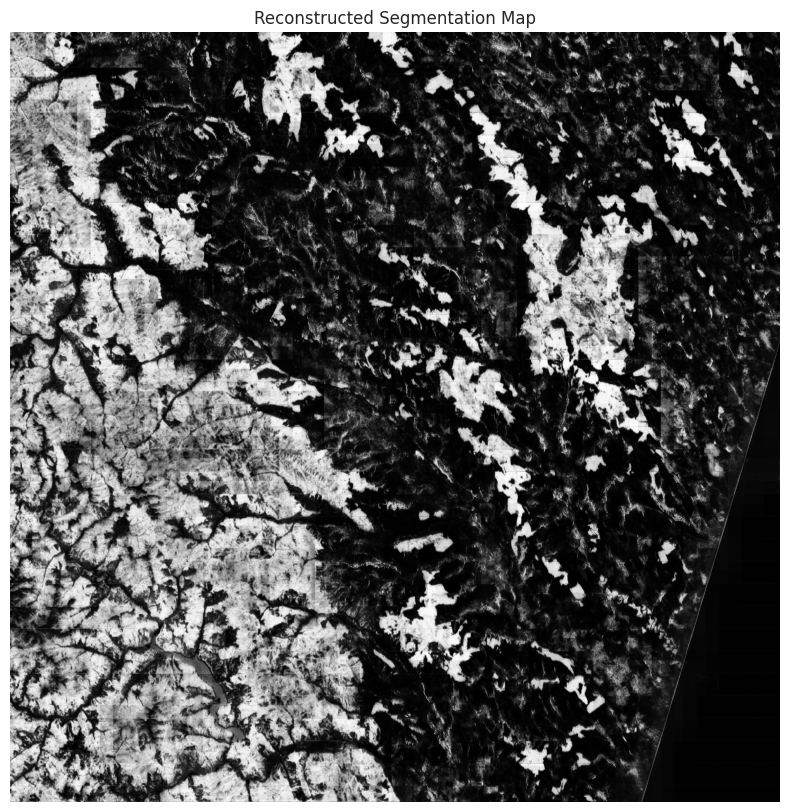

In [17]:
#plot the reconstructed segmentation map
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
plt.imshow(reconstructed_segmentation_map, cmap='gray')
plt.title("Reconstructed Segmentation Map")
plt.axis('off')
plt.show()

Image size: 10980 x 10980


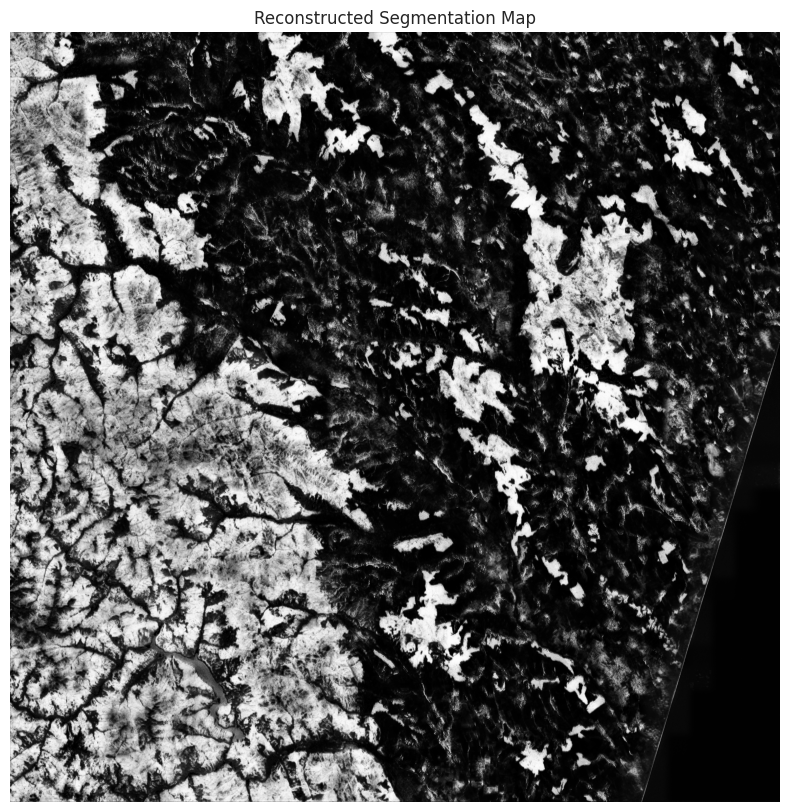

In [18]:
reconstructed_segmentation_map_hanning = reconstruct_image(seg_tiles, seg_positions, tile_width=512,
                      tile_height=512, image_size=(10980, 10980), use_hanning=True)
plt.figure(figsize=(10, 10))
plt.imshow(reconstructed_segmentation_map_hanning, cmap='gray')
plt.title("Reconstructed Segmentation Map")
plt.axis('off')
plt.show()

In [ ]:
#apply threshold otsu
from skimage.filters import threshold_otsu
thresh = threshold_otsu(reconstructed_segmentation_map)
binary_segmentation_map = (reconstructed_segmentation_map >= thresh).astype(np.uint8)

plt.figure(figsize=(10, 10))
plt.imshow(binary_segmentation_map, cmap='gray')
plt.title("Binary Segmentation Map")
plt.axis('off')
plt.show()



In [ ]:
thresh = threshold_otsu(reconstructed_segmentation_map_hanning)
binary_segmentation_map_hanning = (reconstructed_segmentation_map_hanning >= thresh).astype(np.uint8)

plt.figure(figsize=(10, 10))
plt.imshow(binary_segmentation_map_hanning, cmap='gray')
plt.title("Binary Segmentation Map")
plt.axis('off')
plt.show()

In [ ]:
#save the reconstructed image as a geotiff
def save_reconstructed_image(reconstructed_image,
                             meta,
                             output_path):
    # Update metadata for the output file
    meta.update({
        "driver": "COG",
        "height": reconstructed_image.shape[0],
        "width": reconstructed_image.shape[1],
        "count": 1,
        "dtype": 'float32',
        "blockxsize": 256,          # Internal tiling
        "blockysize": 256,
        "compress": "DEFLATE",      # Compression
        "BIGTIFF": "IF_SAFER"       # Use BigTIFF if file >4GB
    })

    with rasterio.open(output_path, 'w', **meta) as dest:
        dest.write(reconstructed_image, 1)

In [ ]:
# hack to get metadata
raw_dir = os.path.join(inference_data_dir, s2_ids[0])
print(s2_ids[0])
bands_files = os.listdir(raw_dir)
meta_hack = None
for f in bands_files:
    if f.endswith('B02.tif'):
        with rasterio.open(os.path.join(raw_dir, f)) as src: # assuming all bands have the same metadata
            meta_hack = src.meta
            break
        # sample_band_file = os.path.join(inference_data_dir, s2_ids[0], f)
        # break

In [ ]:
save_reconstructed_image(reconstructed_segmentation_map_hanning,
                         meta_hack,
                         os.path.join(inference_dir, f"out-{s2_ids[0]}.tif"))